In [1]:
import sys
sys.path.append('/home/carroll/Documents/')

import numpy as np
import os
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
import scipy.io as scio
from scipy.signal import savgol_filter
import asdprocessor
import asd_jump_correction

os.chdir('/home/carroll/Documents/')

# %matplotlib widget

In [ ]:
# prep in situ spectra for use as calibration targets

In [6]:
# 2025
# matterhorn_lot 7/9 (prx + cp)
# mt cb gravel lot 6/26 (prx) - ?
# snodgrass 7/10 (prx) - ?

wl_nan = np.loadtxt('/store/carroll/col/2025/wl_nan.txt')

dat = pd.read_csv('/store/carroll/col/2025/target_rfl_20250723.csv')
dat = dat[dat['file_tag'].isin(['20250626_gravel_lot', '20250709_cp_matterhornlot', '20250709_matterhornlot', '20250710_busstop_prx', '20250710_busstop_cp'])]
rfl_cols = [x for x in dat.columns if x not in ['file_tag', 'date', 'site']]
wl = [float(x) for x in dat.columns if x not in ['file_tag', 'date', 'site']]

# remove the oil slick cp measurement
dat = dat[~((dat['site'] == 'matterhorn_lot_cp') & (dat['350.0'] > 0.09))]

# get mean
mean = dat.drop(columns=['date', 'file_tag']).groupby('site').mean()
mean.columns = wl # column headers to float

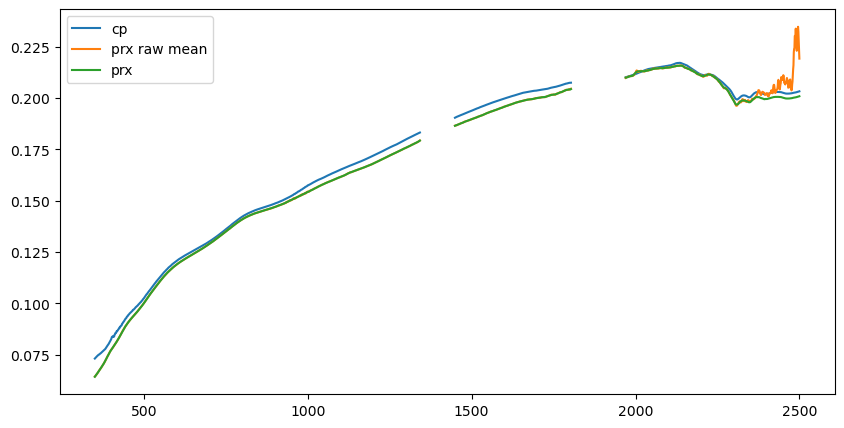

In [7]:
# matterhorn_lot 7/9/25 12:04 MDT

og = mean.loc['matterhorn_lot'].copy()

# smooth the cp measurements > 2400 and < 500
smoothed = savgol_filter(mean.loc['matterhorn_lot_cp'], window_length=25, polyorder=2)
mean.loc[mean.index=='matterhorn_lot_cp', mean.columns<400] = smoothed[mean.columns<400]
mean.loc[mean.index=='matterhorn_lot_cp', mean.columns>2400] = smoothed[mean.columns>2400]

# smooth the prx measurements everywhere
smoothed = savgol_filter(mean.loc['matterhorn_lot'], window_length=25, polyorder=2)
mean.loc[mean.index=='matterhorn_lot', :] = smoothed

# tamp down end using cp
dif = (mean.loc['matterhorn_lot_cp',2310:2340] - mean.loc['matterhorn_lot',2310:2340]).mean()
for i in range(2340, 2501, 1):
    mean.loc['matterhorn_lot',i] = mean.loc['matterhorn_lot_cp',i] - dif

fig = plt.figure(figsize=(10,5))
plt.plot(wl_nan, mean.loc['matterhorn_lot_cp'], label='cp')
plt.plot(wl_nan, og, label='prx raw mean')
plt.plot(wl_nan, mean.loc['matterhorn_lot'], label='prx')
plt.legend()
plt.show()

## also adjust 1960-2015? seems like a noise feature relative to cp
## is the shape around 2375 too weird

Reading files, beginning with /store/carroll/col/2025/insitu/20250707_cp_test_lab_00009.asd...
REF
Using reference_mat as a known white reference spectra.
Number of unique white reference groups detected: 1.0
Total outliers: 0 (>3x std dev: 0, <0.985 cos sim: 0)
asdparabolic 5
Total outliers: 0 (>3x std dev: 0, <0.985 cos sim: 0)


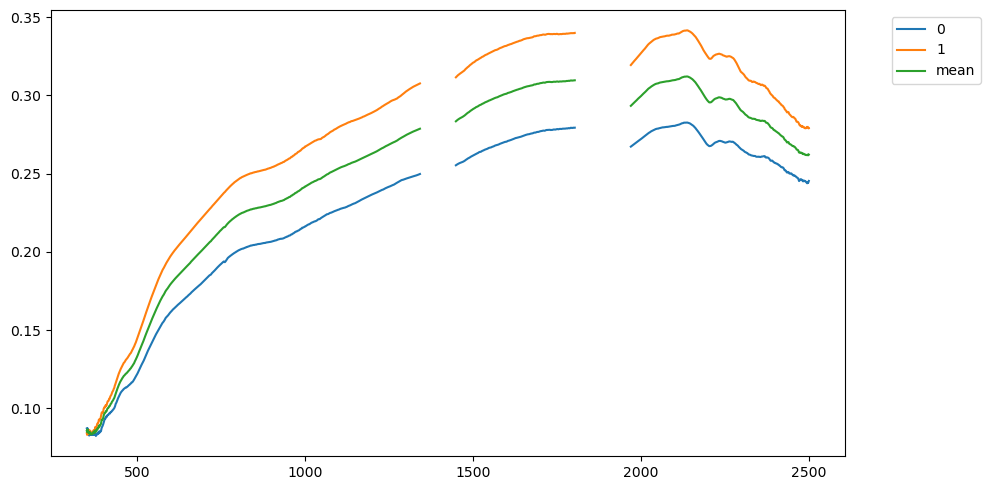

In [8]:
# load, process gravel cp from Kathleen
data_dir = '/store/carroll/col/2025/insitu/'
file_tag = '20250707_cp_test_lab'
proc = asdprocessor.processor(flag_treat_REF_as_RAW = True)
# load raw data
proc.load_asd_files(data_dir,file_tag)
# derive reference_mat, considering true + target wr collections, deriving n of groups, getting group means, interpolating across
proc.process_white_references(interp_method='linear')
# use reference_mat to get reflectance_mat from spectra_mat
proc.calculate_reflectances()
# apply corrections to reflectance_mat
proc.apply_spectralon_rfl_corr() # account for known spectralon rfl
proc.apply_spectralon_45deg_corr() # account for spectralon being at 45 deg to measurement angle 
proc.apply_jump_correction(jump_corr_method='asdparabolic') # apply spectral jump correction at 1000-1001 nm and 1800-1801 nm
proc.calculate_outliers() # find, remove outliers
# derive final rfl_mat with mean, std
rfl_mean, rfl_std, rfl_mat = proc.calculate_final_reflectance()

fig = plt.figure(figsize=(10,5))

for i in range(rfl_mat.shape[0]):
    plt.plot(wl_nan, rfl_mat[i,...], label=i)

plt.plot(wl_nan, rfl_mean, label='mean')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

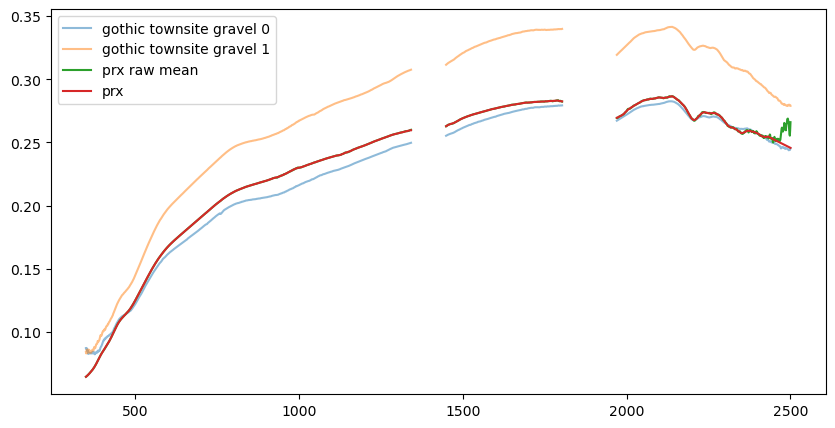

In [9]:
# mt cb gravel lot 6/26/25 13:19 MDT

fig = plt.figure(figsize=(10,5))
for i in range(rfl_mat.shape[0]):
    plt.plot(wl_nan, rfl_mat[i,...], label=f'gothic townsite gravel {i}', alpha=0.5)

# for i in [11,21,31,41,51,61,71]:
#     smoothed = savgol_filter(mean.loc['mt_cb_gravel_lot'], window_length=i, polyorder=2)
#     plt.plot(wl_nan, smoothed, label=f'window {i}')

# smooth
og = mean.loc['mt_cb_gravel_lot'].copy()
smoothed = savgol_filter(mean.loc['mt_cb_gravel_lot'], window_length=31, polyorder=2)
mean.loc[mean.index=='mt_cb_gravel_lot', :] = smoothed

# tamp down the swir2 end by extrapolating local linear trend
fit = (mean.columns >= 2430) & (mean.columns <= 2450)
replace = mean.columns > 2450
wl_ = mean.columns[fit].to_numpy()
rfl_ = mean.loc['mt_cb_gravel_lot', fit].to_numpy()
m, b = np.polyfit(wl_, rfl_, 1) # rfl = m*wl + b
wl_ = mean.columns[replace].to_numpy()
mean.loc['mt_cb_gravel_lot', replace] = m*wl_ + b # extrapolate above 2450
# smooth again?
plt.plot(wl_nan, og, label='prx raw mean')
plt.plot(wl_nan, mean.loc['mt_cb_gravel_lot'], label='prx')

plt.legend()
plt.show()



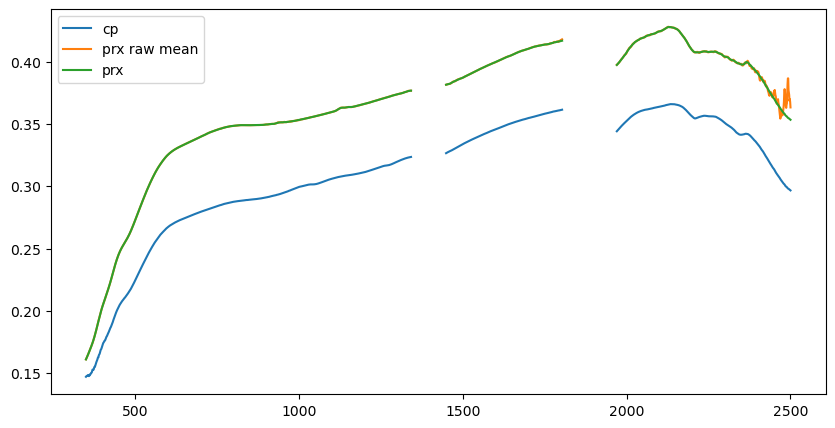

In [10]:
# snoddgrass bus stop 7/10

og = mean.loc['snodgrass_bus_stop'].copy()

# smooth
smoothed = savgol_filter(mean.loc['snodgrass_bus_stop'], window_length=25, polyorder=2)
mean.loc[mean.index=='snodgrass_bus_stop', :] = smoothed

# tamp down end
dif = mean.loc['snodgrass_bus_stop',2375] - mean.loc['snodgrass_bus_stop_cp',2375]
for i in range(2375, 2501, 1):
    mean.loc['snodgrass_bus_stop',i] = mean.loc['snodgrass_bus_stop_cp',i] + dif

# bring up 1800
dif = mean.loc['snodgrass_bus_stop',1776] - mean.loc['snodgrass_bus_stop_cp',1776] # dif at local max
for i in range(1776, 1805, 1):
    mean.loc['snodgrass_bus_stop',i] = mean.loc['snodgrass_bus_stop_cp',i] + dif
    
fig = plt.figure(figsize=(10,5))

plt.plot(wl_nan, mean.loc['snodgrass_bus_stop_cp'], label='cp')
plt.plot(wl_nan, og, label='prx raw mean')
plt.plot(wl_nan, mean.loc['snodgrass_bus_stop'], label='prx')

plt.legend()
plt.show()

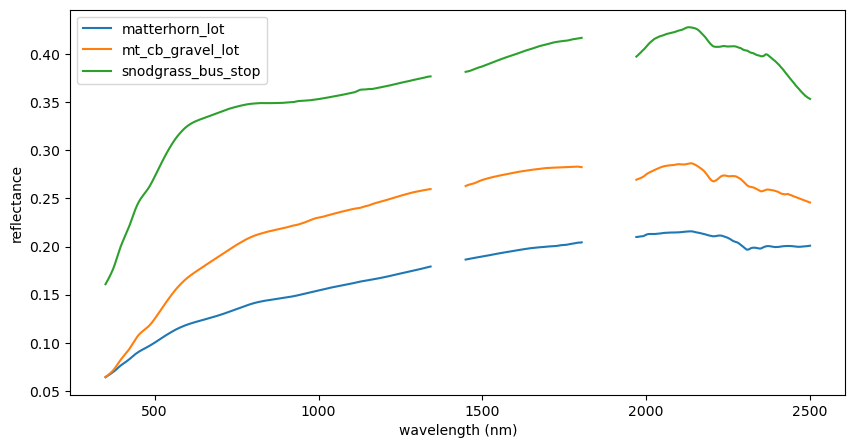

In [11]:
# visualize, export final
mean = mean[mean.index.isin(['matterhorn_lot','mt_cb_gravel_lot','snodgrass_bus_stop'])]

fig = plt.figure(figsize=(10,5))
for idx, row in mean.iterrows():
    plt.plot(wl_nan, row.to_numpy(), label=row.name)
plt.legend()
plt.xlabel('wavelength (nm)')
plt.ylabel('reflectance')
plt.show()

In [ ]:
# export
out = mean.reset_index()
out = out.rename(columns={'index': 'site'})
out['year'] = 2025

out.to_csv('/store/carroll/col/cal_spec_20182025.csv', index=False)

In [14]:
# export formatted for isofit inputs

fol_2018 = '/store/carroll/col/2018/insitu/'
fol_2025 = '/store/carroll/col/2025/'

for idx, row in out.iterrows():
    if row['year']==2018: fol = fol_2018
    else: fol=fol_2025
    fp_out = fol+f'cal_{row['site']}.txt'
    rfl = row[0:2151]
    tmp = np.stack([wavelengths, rfl], axis=1)
    np.savetxt(fp_out, tmp)

In [15]:
# borrowing wavelength file from usgs? to get fwhm
# https://www.usgs.gov/data/reflectance-spectra-collected-august-21-2022-black-rock-desert-nevada-asd-fieldspec-4-hi-res]
wvl = np.loadtxt('/store/carroll/col/BlackRockDesertNV_21aug2022_ASDprobe_AVGspectrum.txt', skiprows=7)
wvl = wvl[:,0:2]
wvl[:,0] = wvl[:,0]*1000
# wvl[:,0] = wl # substitute with the other values

# np.savetxt(fol_2018+'wavelengths.txt', wvl)
# np.savetxt(fol_2025+'wavelengths.txt', wvl)

# I have since decided that this is totally unnecessary

In [17]:
# convert isofit formatting to neon wavelengths

wl_asd = np.loadtxt('/store/carroll/col/BlackRockDesertNV_21aug2022_ASDprobe_AVGspectrum.txt', skiprows=7)[:,0]
wl_neon = np.loadtxt('/store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250731/data/wavelengths.txt')[:,1]
fwhm_neon = np.loadtxt('/store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250731/data/wavelengths.txt')[:,2]

fol_2018 = '/store/carroll/col/2018/insitu/'
fol_2025 = '/store/carroll/col/2025/'

rfl_asd = np.loadtxt(fol_2018+'cal_black_tarp.txt')[:,1]

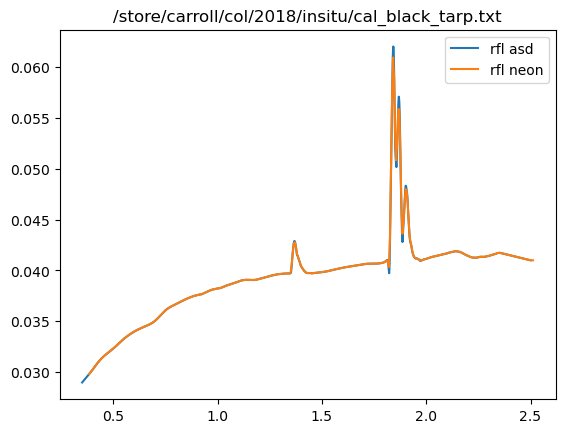

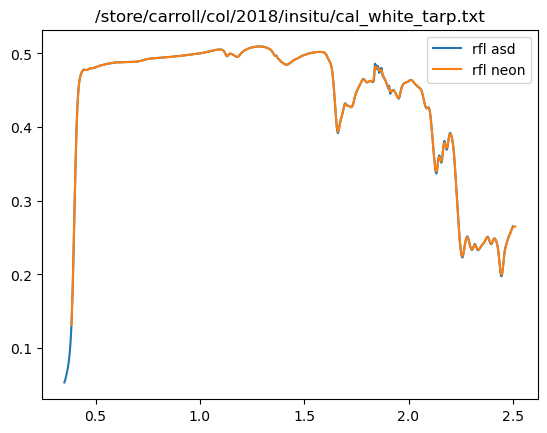

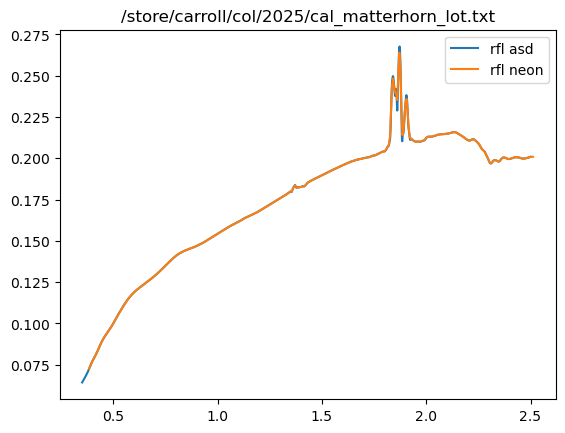

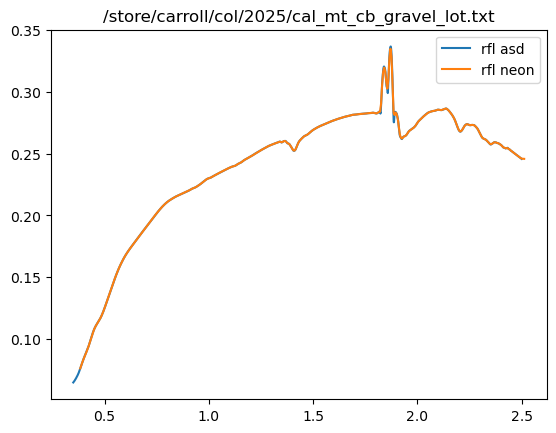

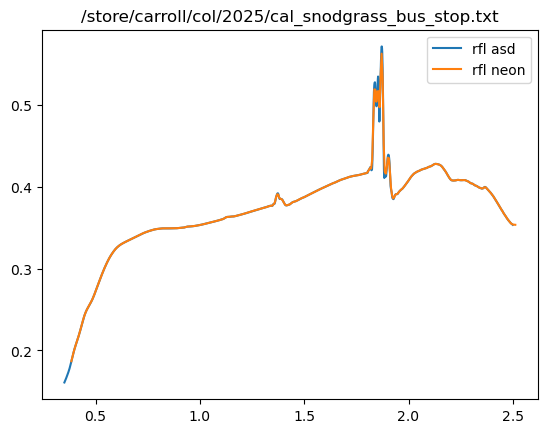

In [18]:
fps = glob('/store/carroll/col/**/cal*.txt', recursive=True)
fps = [x for x in fps if 'neon' not in x]

for fp in fps:
    rfl_asd = np.loadtxt(fp)[:,1]
    rfl_neon = np.zeros_like(wl_neon)
    for i, (center, fwhm) in enumerate(zip(wl_neon, fwhm_neon)):
        sigma = fwhm / (2*np.sqrt(2*np.log(2)))  # Convert FWHM → Gaussian σ
        weights = np.exp(-0.5 * ((wl_asd - center) / sigma)**2)
        weights /= np.sum(weights)               # Normalize weights
        rfl_neon[i] = np.sum(rfl_asd * weights)     # Weighted average
    rfl_neon = np.stack([wl_neon, rfl_neon], axis=1)
    # np.savetxt(fp.replace('.txt', '_neon.txt'), rfl_neon)

    fig = plt.figure()
    plt.plot(wl_asd, rfl_asd, label='rfl asd')
    plt.plot(wl_neon, rfl_neon[:,1], label='rfl neon')
    plt.title(fp)
    plt.legend()
    plt.show()

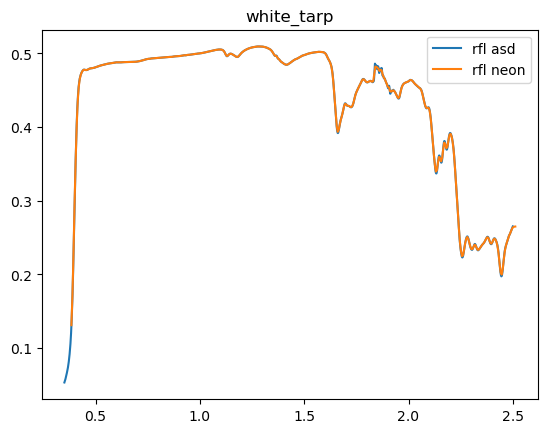

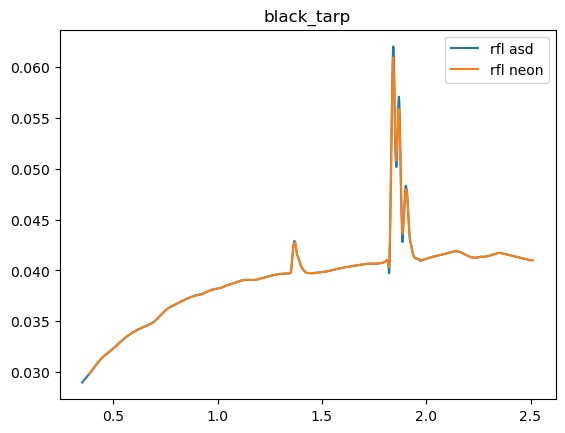

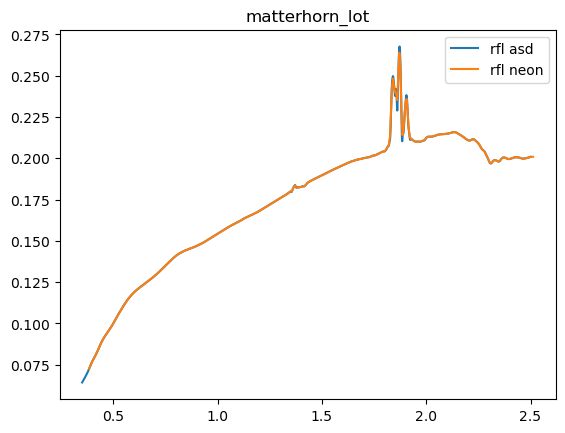

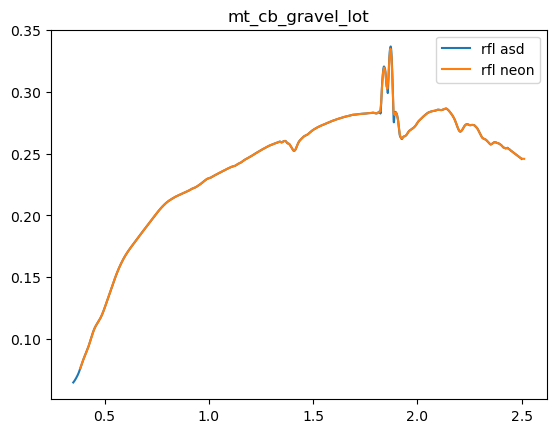

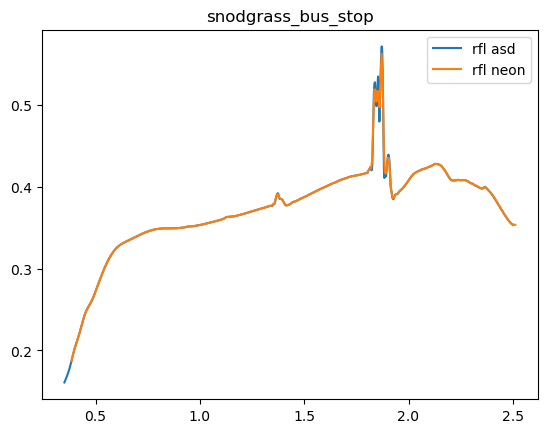

In [19]:
# convert csv to neon wavelengths

df = pd.read_csv('/store/carroll/col/cal_spec_20182025.csv')

# set up empty neon df
df_neon = df[['year','site']]
df_neon.loc[:,[x for x in wl_neon]] = pd.NA

for idx, row in df.iterrows():
    rfl_asd = row[0:2151]
    rfl_neon = np.zeros_like(wl_neon)
    for i, (center, fwhm) in enumerate(zip(wl_neon, fwhm_neon)):
        sigma = fwhm / (2*np.sqrt(2*np.log(2)))  # Convert FWHM → Gaussian σ
        weights = np.exp(-0.5 * ((wl_asd - center) / sigma)**2)
        weights /= np.sum(weights)               # Normalize weights
        rfl_neon[i] = np.sum(rfl_asd * weights)     # Weighted average

    # df_neon.loc[df_neon.site =='white_tarp'].iloc[:,0:429] = rfl_neon
    df_neon.loc[df_neon.site ==row['site'], [col for col in df_neon.columns if col not in ['year', 'site']]] = rfl_neon

    fig = plt.figure()
    plt.plot(wl_asd, rfl_asd, label='rfl asd')
    plt.plot(wl_neon, rfl_neon, label='rfl neon')
    plt.title(row['site'])
    plt.legend()
    plt.show()

df_neon.to_csv('/store/carroll/col/cal_spec_20182025_neon.csv', index=False)